# Device

In [ ]:
from core.utils.utils import get_device

In [2]:
DEVICE = get_device()
DEVICE

device(type='cuda', index=0)

# DAVE Explainer

In [3]:
from pathlib import Path
from core.explainer import DAVEExplainer

In [4]:
MODEL_CONFIG: Path = Path('models_configs')/'deit3_b16_224.yaml'

In [5]:
dave_explainer = DAVEExplainer(
    model_cfg_path=MODEL_CONFIG,
    device=DEVICE,
)

# Data Loader 
### (single Image, multiple Labels)

In [6]:
from pathlib import Path

In [7]:
DATA_DIR: Path = Path('data_samples/multiclass_samples')

### Example I: Panda, Tiger, SoccerBall

In [8]:
IMAGE_NAME = 'image_0.png'
LABELS = [388, 292, 805]

### Example II: Dalmitian, TennisBall, Lawnmower

In [9]:
# IMAGE_NAME = 'image_1.png'
# LABELS = [251, 852, 621]

In [10]:
from torch.utils.data import DataLoader
from core.utils.utils import load_pil_image
from core.utils.data import SingleImageMultiLabelDataset

In [11]:
transform = dave_explainer.input_transform

dataset = SingleImageMultiLabelDataset(
    image=load_pil_image(DATA_DIR/IMAGE_NAME),
    labels=LABELS,
    transform=transform
)

In [12]:
data_loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=False
)

# Attribute and visualize

In [13]:
from tqdm import tqdm
from core.utils.visualization import visualize_attribution_batch

In [14]:
NUM_STEPS: int = 100

Attributing...:   0%|          | 0/3 [00:00<?, ?it/s]

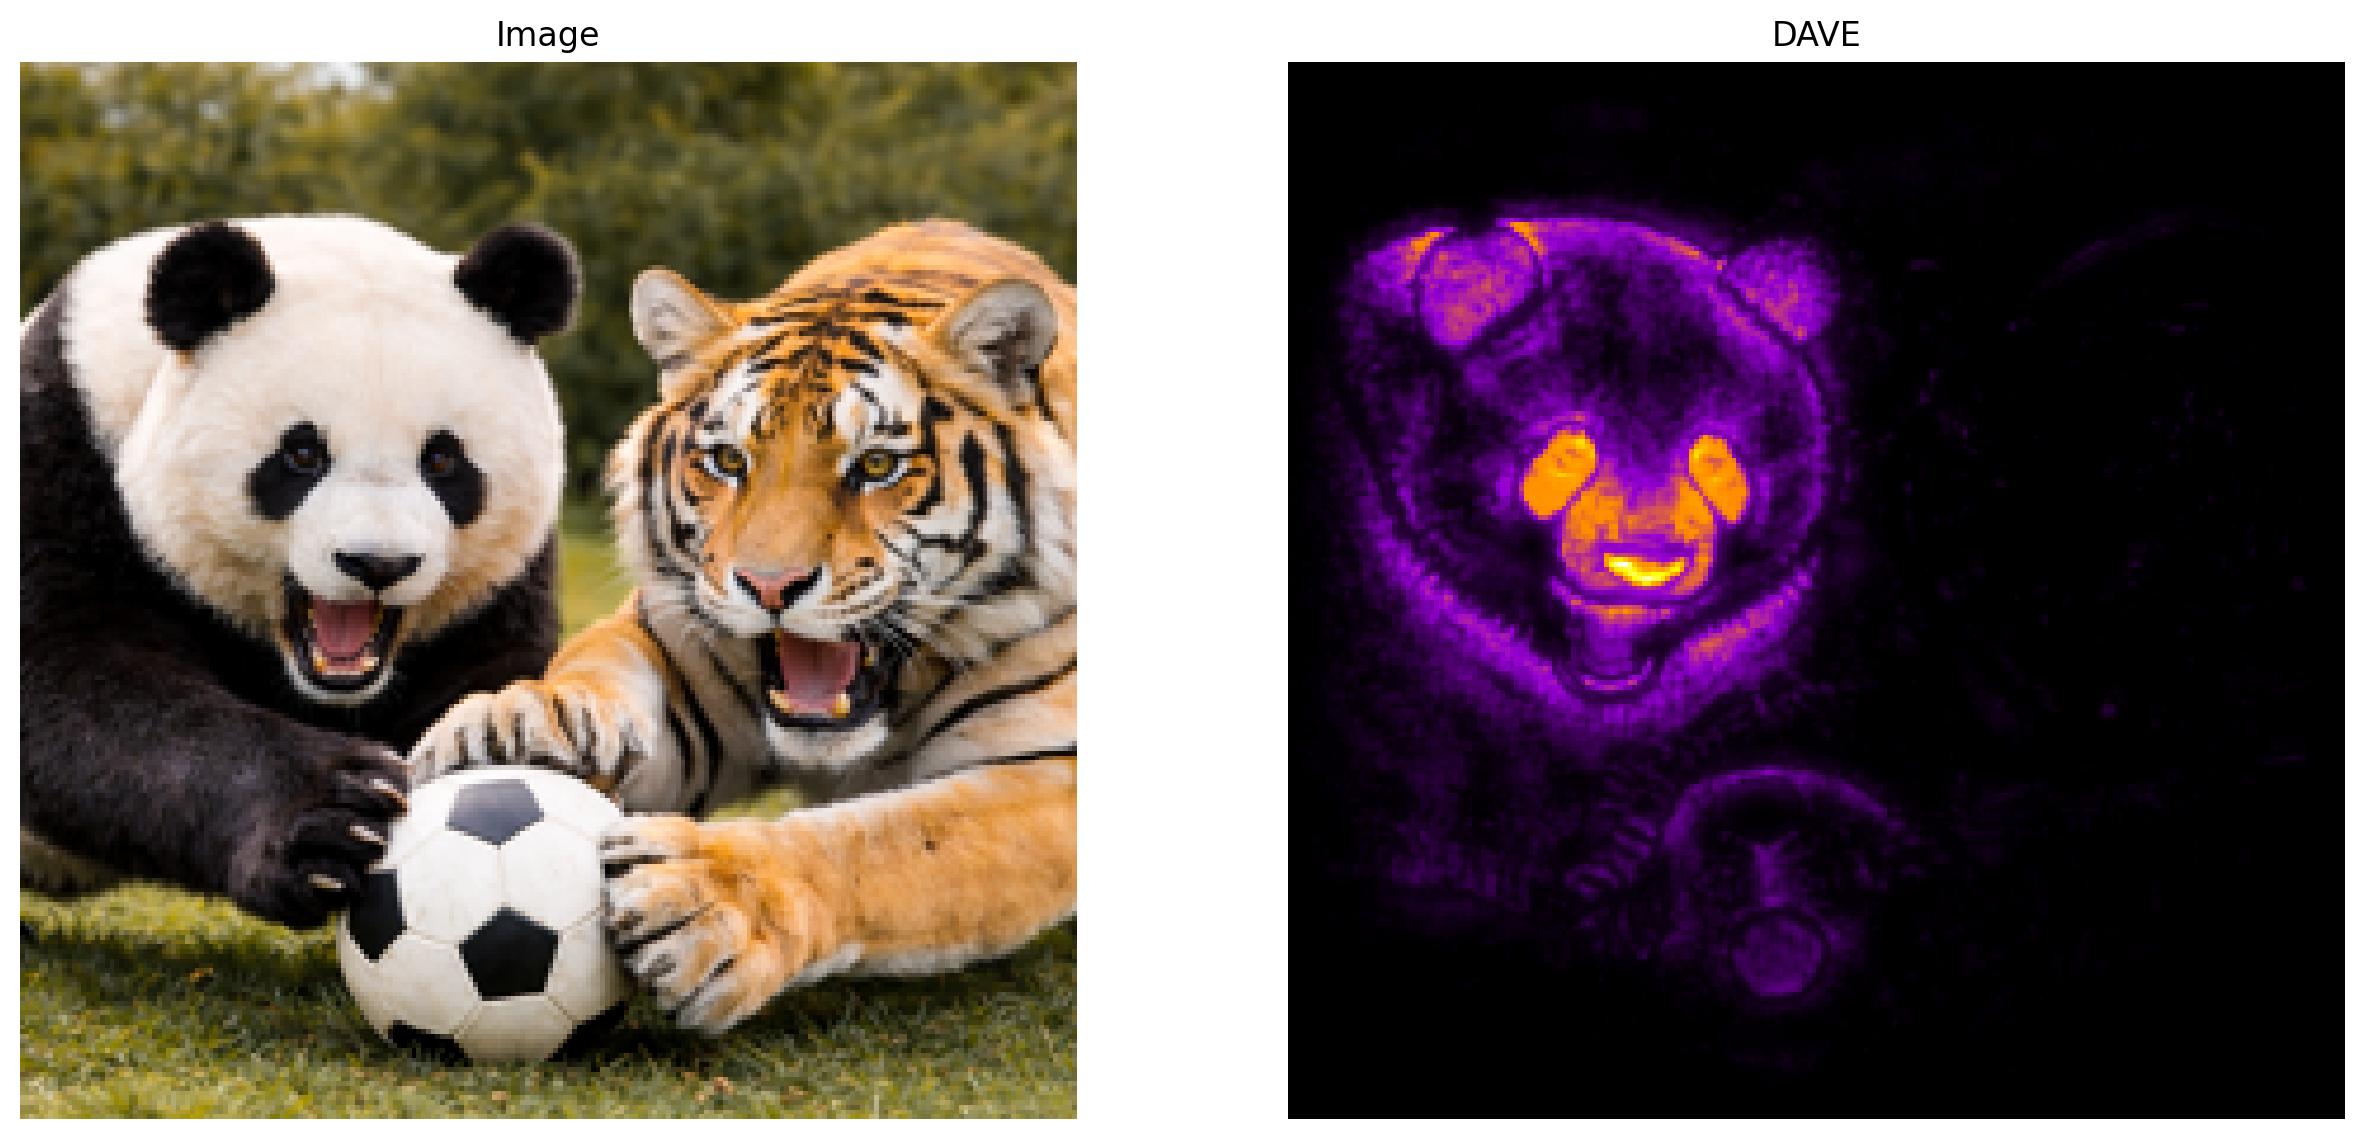

Attributing...:  33%|███▎      | 1/3 [00:05<00:10,  5.04s/it]

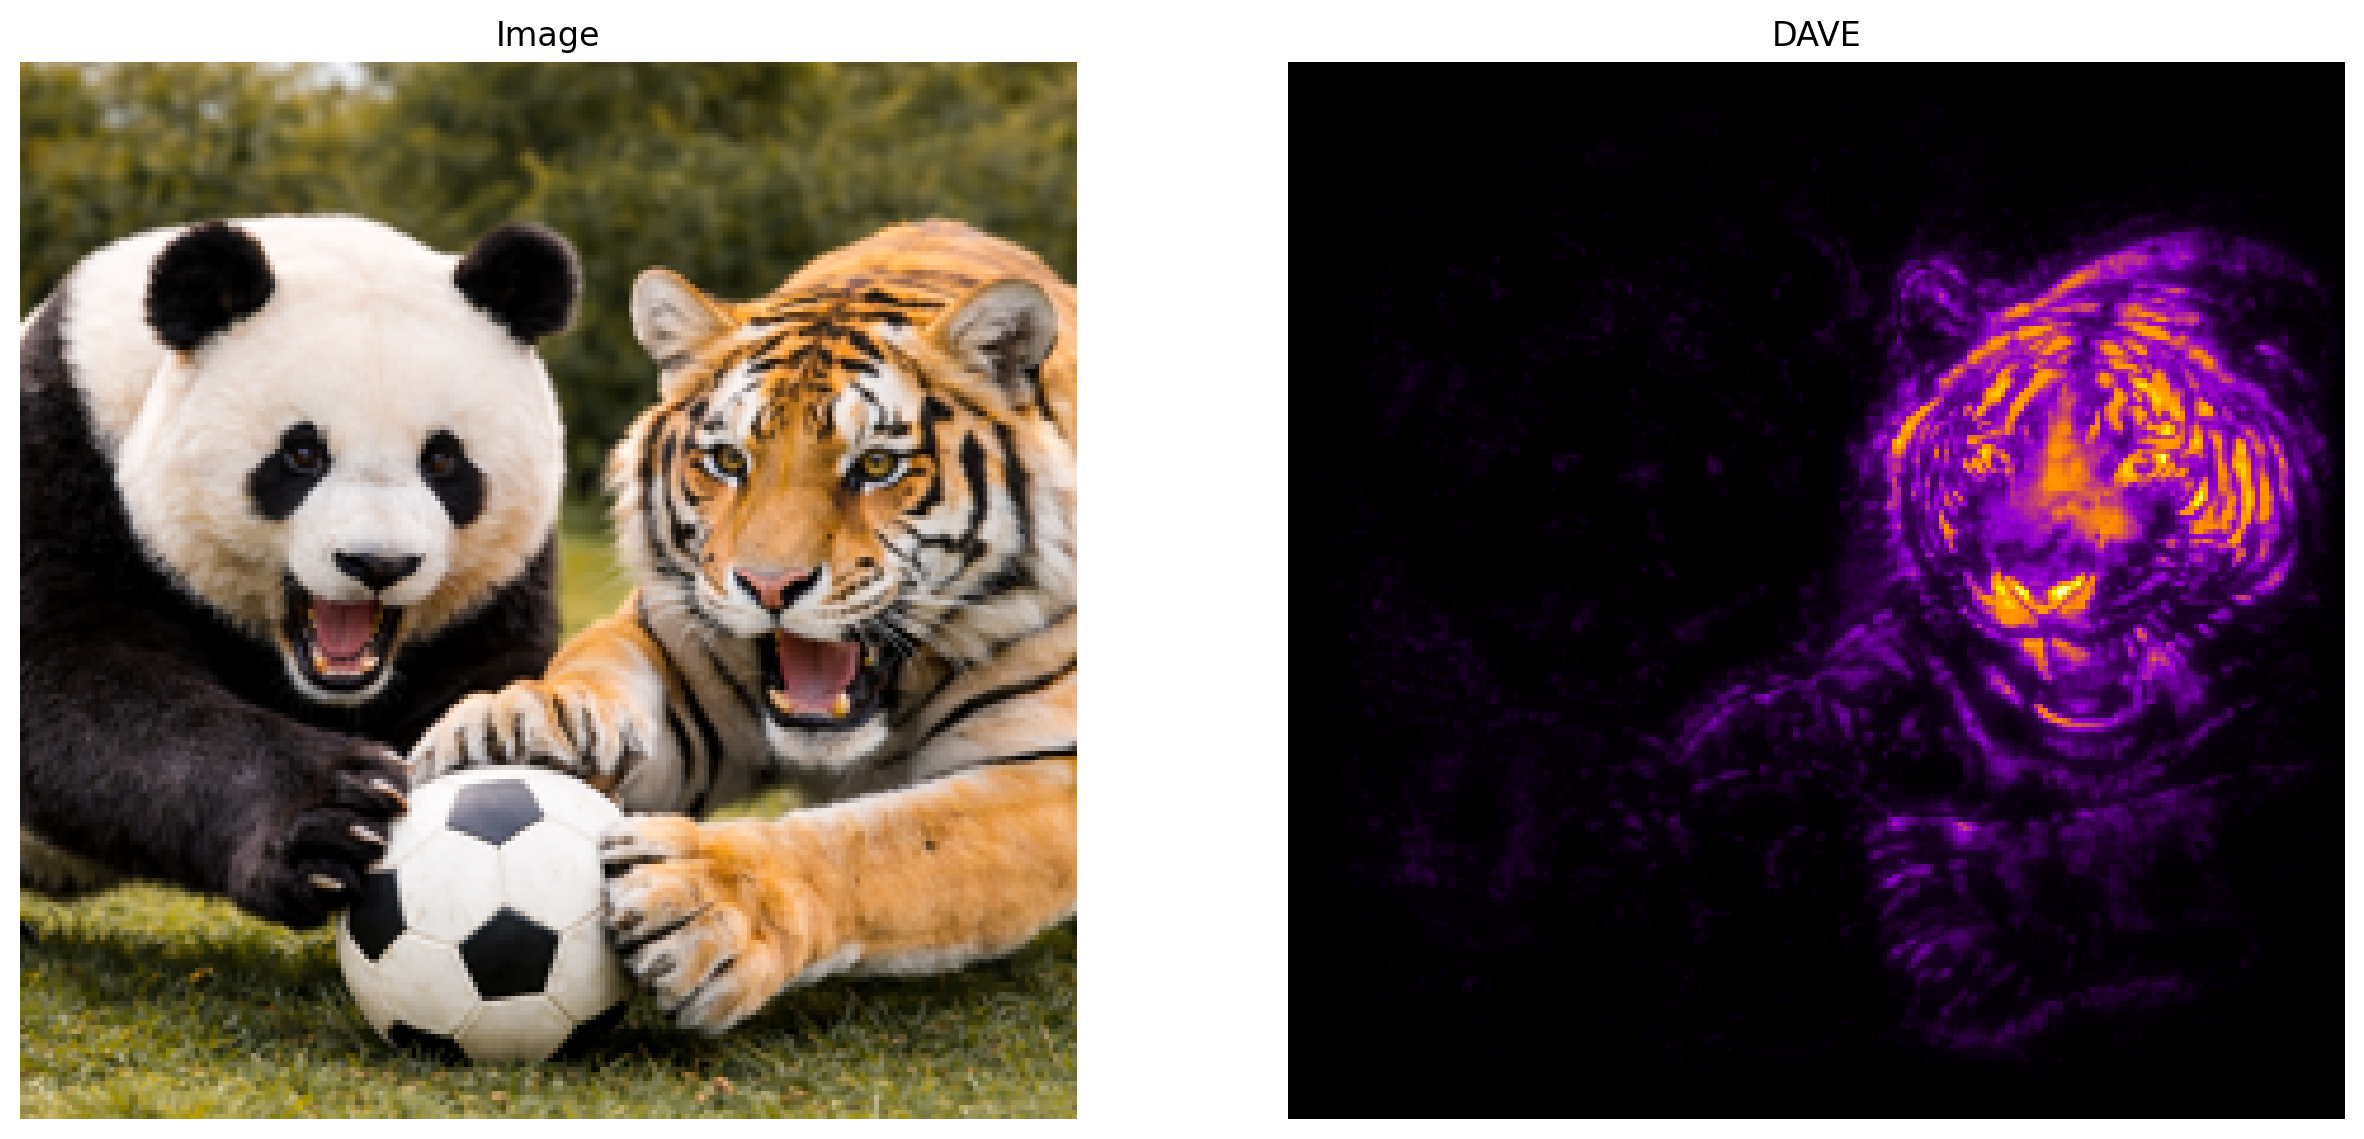

Attributing...:  67%|██████▋   | 2/3 [00:09<00:04,  4.87s/it]

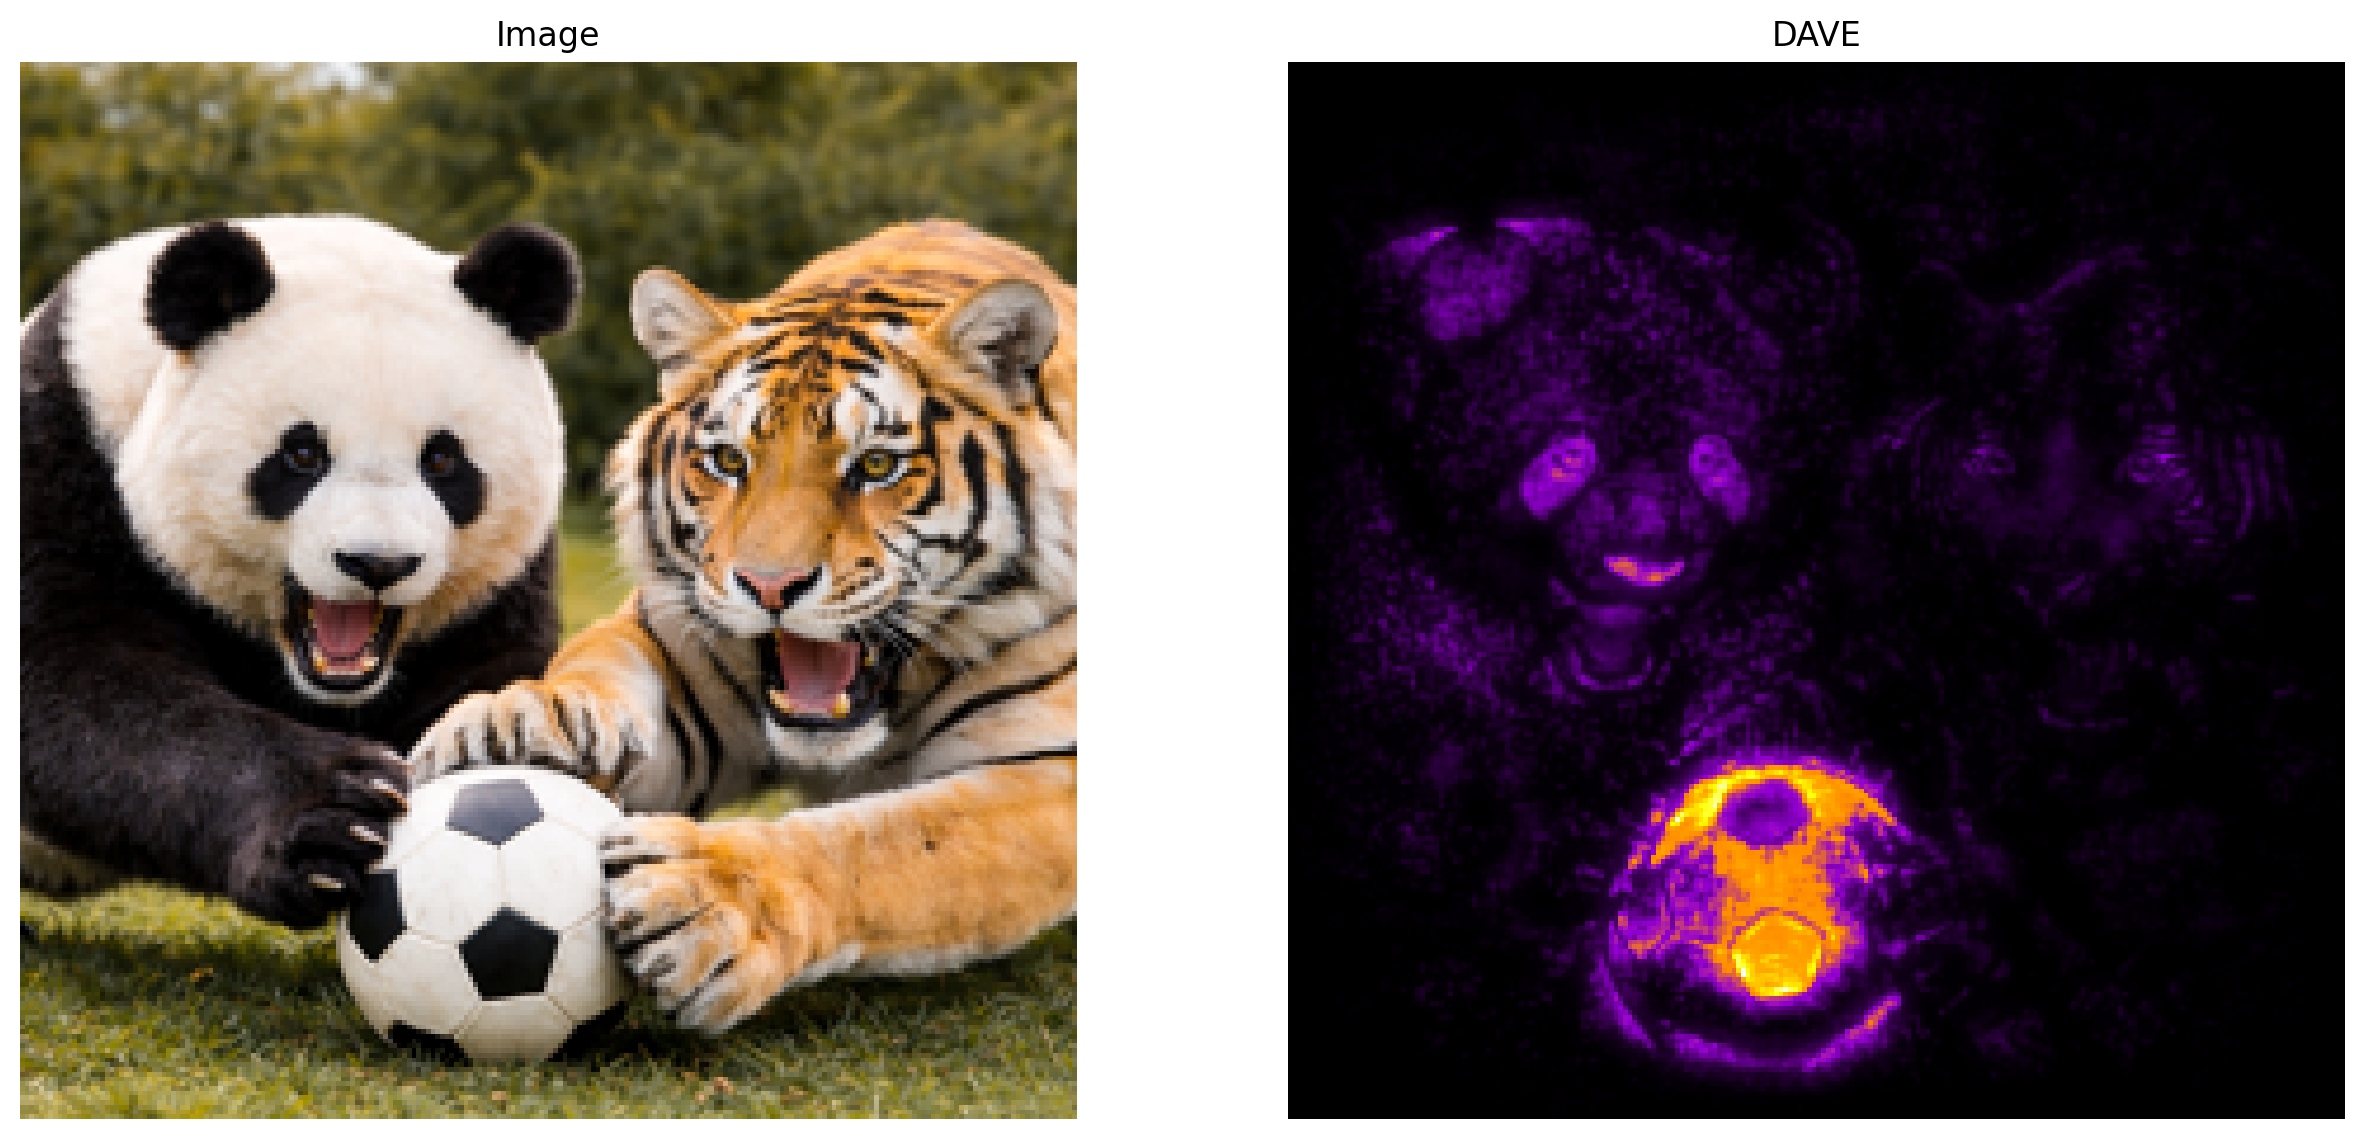

Attributing...: 100%|██████████| 3/3 [00:14<00:00,  4.86s/it]


In [15]:
for x, y in tqdm(
    data_loader,
    desc="Attributing...",
    total=len(data_loader),
):
    x, y = x.to(DEVICE), y.to(DEVICE)
    
    a = dave_explainer.explain(
        x=x, 
        y=y, 
        num_steps=NUM_STEPS,
        post_proc=True,
    )

    visualize_attribution_batch(
        attribution_map=a, 
        image_batch=x, 
        input_transform=transform,
    )